Plot the electric field of a uniformly magnetised, rotating sphere. The electric field components are:
\begin{align}
E_r(r>R) &= -\frac{8\pi R^5 \omega M_0}{3cr^4}P_2(\cos\theta)\\
E_\theta(r>R) &= -\frac{4\pi R^5 \omega M_0}{3 cr^4}\sin 2\theta
\end{align}

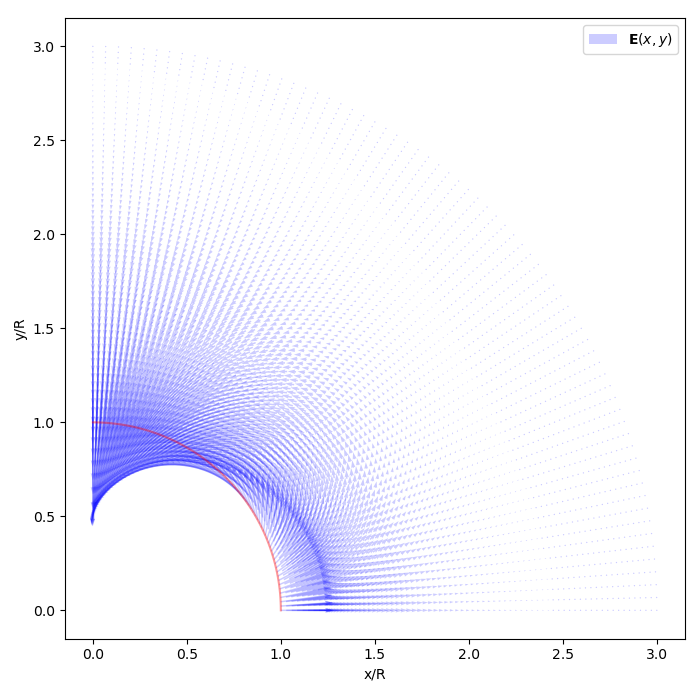

In [45]:
import numpy as np
from matplotlib import pyplot as plt

%matplotlib widget
# create grid in (r,theta)
R = 1
M_0 = 1
c = 1
omega = 0.1
r = np.linspace(R,3*R,70)
th = np.linspace(0,np.pi/2,70)

thg,rg = np.meshgrid(th,r)

p2 = np.polynomial.legendre.legval(np.cos(thg),[0,0,1])

E_r = -8*np.pi*R**5*omega*M_0/(3*c*rg**4)*p2
E_th = -4*np.pi*R**5*omega*M_0/(3*c*rg**4)*np.sin(2.*thg)

E_mag = np.sqrt(E_r**2 + E_th**2)

E_x = np.sin(thg)*E_r + np.cos(thg)*E_th
E_y = np.cos(thg)*E_r - np.sin(thg)*E_th

xg = rg*np.sin(thg)
yg = rg*np.cos(thg)

x_surface = R*np.sin(th)
y_surface = R*np.cos(th)

fig,ax = plt.subplots(figsize=(7,7))
# ax.contourf(xg,yg,E_mag,levels=100,alpha = 0.4)
ax.quiver(xg,yg,E_x,E_y,scale=5,alpha = 0.2, color='blue',label=r"$\mathbf{E}(x,y)$")
ax.set_aspect('equal')
ax.set(xlabel='x/R',ylabel='y/R')
ax.plot(x_surface,y_surface,alpha=0.4,c='r')
fig.tight_layout()
ax.legend()
plt.show()
